In [7]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("C:/Users/Administrator/PythonProjects/discharge_queich/")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
os.getcwd()

'C:\\Users\\Administrator\\PythonProjects\\discharge_queich'

In [9]:
os.chdir("C:/Users/Administrator/PythonProjects/discharge_queich/src")

from pathlib import Path

from urllib.parse import urljoin
import requests
from bs4 import BeautifulSoup, Tag
import pandas as pd

from src.discharge_queich.configs import settings
from src.discharge_queich.utils.logger import logger
from src.discharge_queich.jobs.temp.stations import STATIONS


os.chdir("C:/Users/Administrator/PythonProjects/discharge_queich")

In [10]:
temp_settings = settings.ingestion.temp

## Read temp

In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from discharge_queich.jobs.temp.process_temp import build_mean_temp_timeseries

2026-07-10 00:00:00
2026-07-10 13:15:00


<Axes: xlabel='timestamp'>

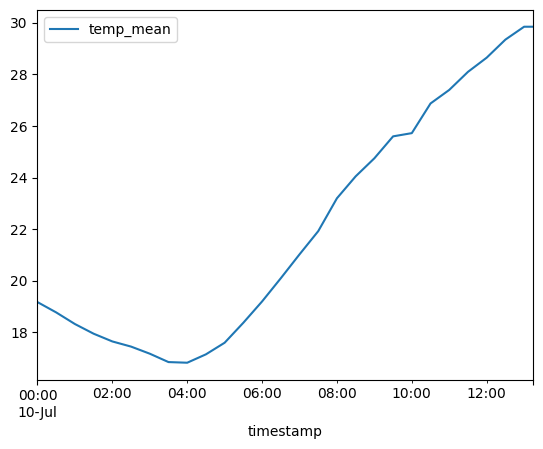

In [12]:
df = build_mean_temp_timeseries(start=None)
print(df.index.min())
print(df.index.max())
df.plot()

## Ingest recent temp


In [29]:
def get_upload_time(html_tag: Tag) -> pd.Timestamp | None:

    tail = str(html_tag.next_sibling)
    
    if tail is None:
        return None
    
    parts = tail.strip().split()
    
    upload_time = pd.to_datetime(
        f"{parts[0]} {parts[1]}",
        dayfirst=True
    )
    
    return upload_time


def get_station_id(href: str) -> str:
    
    _, _, station_id, _ = href.split("_", maxsplit=3)
    
    return station_id


def fetch_temp_metadata(
    url: str | Path,
    station_ids: list[str],
    ) -> pd.DataFrame:
    
    try:
        response = requests.get(str(url), timeout=30)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")
        
        
        rows = []

        for a in soup.find_all("a"):

            # Get filename
            href = str(a.get("href"))
            
            if not href:
                continue

            if not href.endswith(".zip"):
                continue
            
            if all(station not in href for station in station_ids):
                continue
            
            file_url = urljoin(str(url), href)
            station_id = get_station_id(href=href)
            upload_time = get_upload_time(html_tag=a)
            
            if upload_time is None:
                continue
            
            
            rows.append({
                        "station_id": station_id,
                        "filename": href,
                        "file_url": file_url,
                        "datetime_upload": upload_time,
                    })

        return pd.DataFrame(rows)
    
    
    except requests.RequestException as e:
        logger.exception("Failed to fetch icon metadata from %s", url)
        raise


In [30]:
def download_temp_file(
    url: str,
    file_name: str,
    output_dir: str
    ) -> None:
    
    output_path = Path(output_dir) / file_name
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    
    try:
        logger.info("Downloading %s", file_name)    
        
        with requests.get(url, timeout=30, stream=True) as r:
                    
            r.raise_for_status()

            with open(output_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
        
        logger.info("Saved file to %s", output_path)
        
        
    except requests.RequestException:
        logger.exception("Failed downloading file: %s", url)
        raise
    
    
    except OSError:
        logger.exception("Failed writing file: %s", output_path)
        raise

In [31]:
from src.discharge_queich.jobs.temp.stations import STATIONS

temp_recent_settings = settings.ingestion.temp_recent

df_remote = fetch_temp_metadata(
        url=temp_recent_settings.url, 
        station_ids=STATIONS
        )

# df_remote = fetch_temp_metadata(
#         url="https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/10_minutes/air_temperature/recent/", 
#         station_ids=STATIONS
#         )

In [35]:
for _, row in df_remote.iterrows():
    
    station_id = row["station_id"]
    file_url = row["file_url"]
    file_name = row["filename"]
    
    download_temp_file(
        url=file_url,
        file_name=file_name,
        output_dir=temp_recent_settings.compressed_dir
    )


2026-07-11 19:03:09,800 | 1216247944.py | INFO | Downloading 10minutenwerte_TU_00377_akt.zip
2026-07-11 19:03:10,632 | 1216247944.py | INFO | Saved file to data\observed_temp\recent\10minutenwerte_TU_00377_akt.zip
2026-07-11 19:03:10,641 | 1216247944.py | INFO | Downloading 10minutenwerte_TU_02486_akt.zip
2026-07-11 19:03:11,122 | 1216247944.py | INFO | Saved file to data\observed_temp\recent\10minutenwerte_TU_02486_akt.zip
2026-07-11 19:03:11,133 | 1216247944.py | INFO | Downloading 10minutenwerte_TU_03939_akt.zip
2026-07-11 19:03:11,531 | 1216247944.py | INFO | Saved file to data\observed_temp\recent\10minutenwerte_TU_03939_akt.zip
2026-07-11 19:03:11,548 | 1216247944.py | INFO | Downloading 10minutenwerte_TU_05426_akt.zip
2026-07-11 19:03:13,785 | 1216247944.py | INFO | Saved file to data\observed_temp\recent\10minutenwerte_TU_05426_akt.zip


In [52]:
from discharge_queich.database.db import SessionLocal
from discharge_queich.database.models import TempStationObservation

def write_to_db(df: pd.DataFrame) -> None:
    with SessionLocal() as session:
    
        try:
            for timestamp, row in df.iterrows():
                
                entry = TempStationObservation(
                    timestamp=timestamp,
                    temp_mean=row["temp_mean"]
                )
                
                session.merge(entry)
                
            session.commit()
            
            logger.info("[STATIONS TEMP OBSERV] Inserted %s rows.", len(df))

        
        except Exception:
            session.rollback()
            logger.exception("[STATIONS TEMP OBSERV] Failed DB ingestion.")
            raise
        

def subset_timeseries(df: pd.DataFrame) -> pd.Series:
    
    latest = df.index.max()
    cutoff = latest - pd.DateOffset(months=1)

    return df[df.index >= cutoff]

False
52800


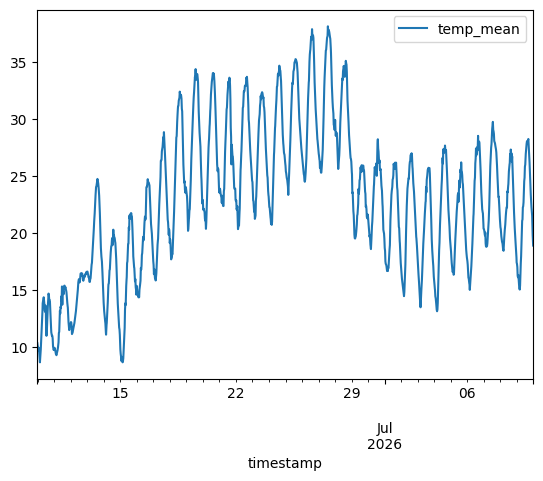

In [53]:
df = build_mean_temp_timeseries(
    compressed_dir="data/observed_temp/recent",
    start=None
    )


df_sub = subset_timeseries(df=df)

# df.plot()
df_sub.plot()

print(df.isna().values.any())
print(len(df))

In [59]:
write_to_db(df=df_sub)

2026-07-10 18:55:08,067 | 2351925923.py | INFO | [STATIONS TEMP OBSERV] Inserted 2881 rows.


## Check folder

In [20]:
from discharge_queich.jobs.temp.recent.fetch_temp import fetch_temp
from discharge_queich.jobs.temp.recent.ingest_temp import main 

In [21]:
main()

2026-07-12 16:52:14,732 | fetch_temp.py | INFO | Downloading 10minutenwerte_TU_00377_akt.zip
2026-07-12 16:52:15,501 | fetch_temp.py | INFO | Saved file to data\observed_temp\recent\10minutenwerte_TU_00377_akt.zip
2026-07-12 16:52:15,504 | fetch_temp.py | INFO | Downloading 10minutenwerte_TU_02486_akt.zip
2026-07-12 16:52:15,915 | fetch_temp.py | INFO | Saved file to data\observed_temp\recent\10minutenwerte_TU_02486_akt.zip
2026-07-12 16:52:15,916 | fetch_temp.py | INFO | Downloading 10minutenwerte_TU_03939_akt.zip
2026-07-12 16:52:16,368 | fetch_temp.py | INFO | Saved file to data\observed_temp\recent\10minutenwerte_TU_03939_akt.zip
2026-07-12 16:52:16,382 | fetch_temp.py | INFO | Downloading 10minutenwerte_TU_05426_akt.zip
2026-07-12 16:52:16,839 | fetch_temp.py | INFO | Saved file to data\observed_temp\recent\10minutenwerte_TU_05426_akt.zip
2026-07-12 16:52:22,313 | ingest_temp.py | INFO | [STATIONS TEMP OBSERV] Inserted 2881 rows.


## Read temp

In [22]:
from discharge_queich.database.queries import load_temp_observation_data, load_precip_forecast_data

In [14]:
def prepare_forecast_df(
    df: pd.DataFrame,
    days: int,
    ) -> pd.DataFrame:
    
    # --- Datetime ---
    if "timestamp" in df.columns.to_list():
        df = df.set_index(keys=["timestamp"])
    
    df.index = pd.to_datetime(df.index)
    
     # --- Set cutoff ---
    latest = df.index.max()
    cutoff = latest - pd.Timedelta(days=days)
    
    df = df[df.index >= cutoff]
    
    return df

2026-07-14 00:00:00
2026-07-14 00:00:00


<Axes: xlabel='timestamp'>

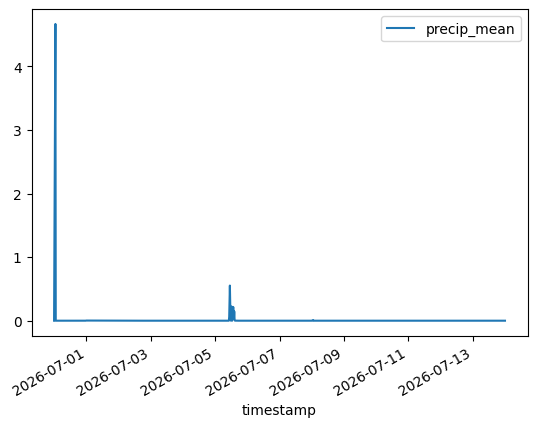

In [15]:
df = load_precip_forecast_data()
print(df.index.max())

df = prepare_forecast_df(df, days=14)

print(df.index.max())

df.plot()

                     temp_mean
timestamp                     
2026-07-12 12:45:00     30.025
2026-07-12 13:00:00     30.200
2026-07-12 13:15:00     30.325
2026-07-12 13:30:00     30.450
2026-07-12 13:45:00     30.450


<Axes: xlabel='timestamp'>

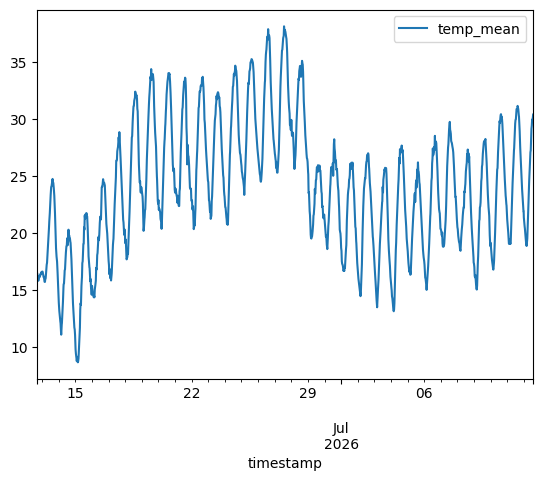

In [23]:
df = load_temp_observation_data()
print(df.tail())
df.plot()